# Lesson 3
## MakeMore model

# uses character sequences and attempts to predict the next character (character-level language model)

In [31]:
import sys
from pathlib import Path

# Add the parent directory (nnz2h) to sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

import pygrad

import math
import numpy as np
import matplotlib.pyplot as plt
import random

# jupyter magic:
%matplotlib inline

In [32]:
words = open('names.txt','r').read().splitlines()


MakeMore looks at the name and the following letters and is trained by looking at a certain letter and using previous names to assess what is likely next (includes the end too)

# Bigram model
2 letters at a time, for example if it starts with a, what is most likely to follow a

In [33]:
for w in words[:1]: # iterates through a word 2 letters at a time
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1,ch2)

e m
m m
m a


In [34]:
for w in words[:1]: # need to make the start and end stand out with special tokens
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>


In [35]:
b = {} # stores the bigrams for analysis later
for w in words: # need to make the start and end stand out with special tokens
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1


In [36]:
sorted(b.items(), key = lambda kv: -kv[1]) # sorts by the frequency rather than letter

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

Python dictonary is not too efficient on larger scales for storing this data, instead we should store in a matrix (what!?!?!?) where first column is the bigram and second is frequency

In [37]:
import torch # want their tensors

In [38]:
N = torch.zeros((28, 28), dtype=torch.int32) # create initial array

Create a proper way to store the code

In [39]:
chars = sorted(list(set(''.join(words)))) # characters
stoi ={s:i for i,s in enumerate(chars)} # enumerate gives us an iterator over the characters
stoi['<S>'] = 26
stoi['<E>'] = 27

In [40]:
for w in words: # need to make the start and end stand out with special tokens
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 # stores frequency of the letter in the matrix

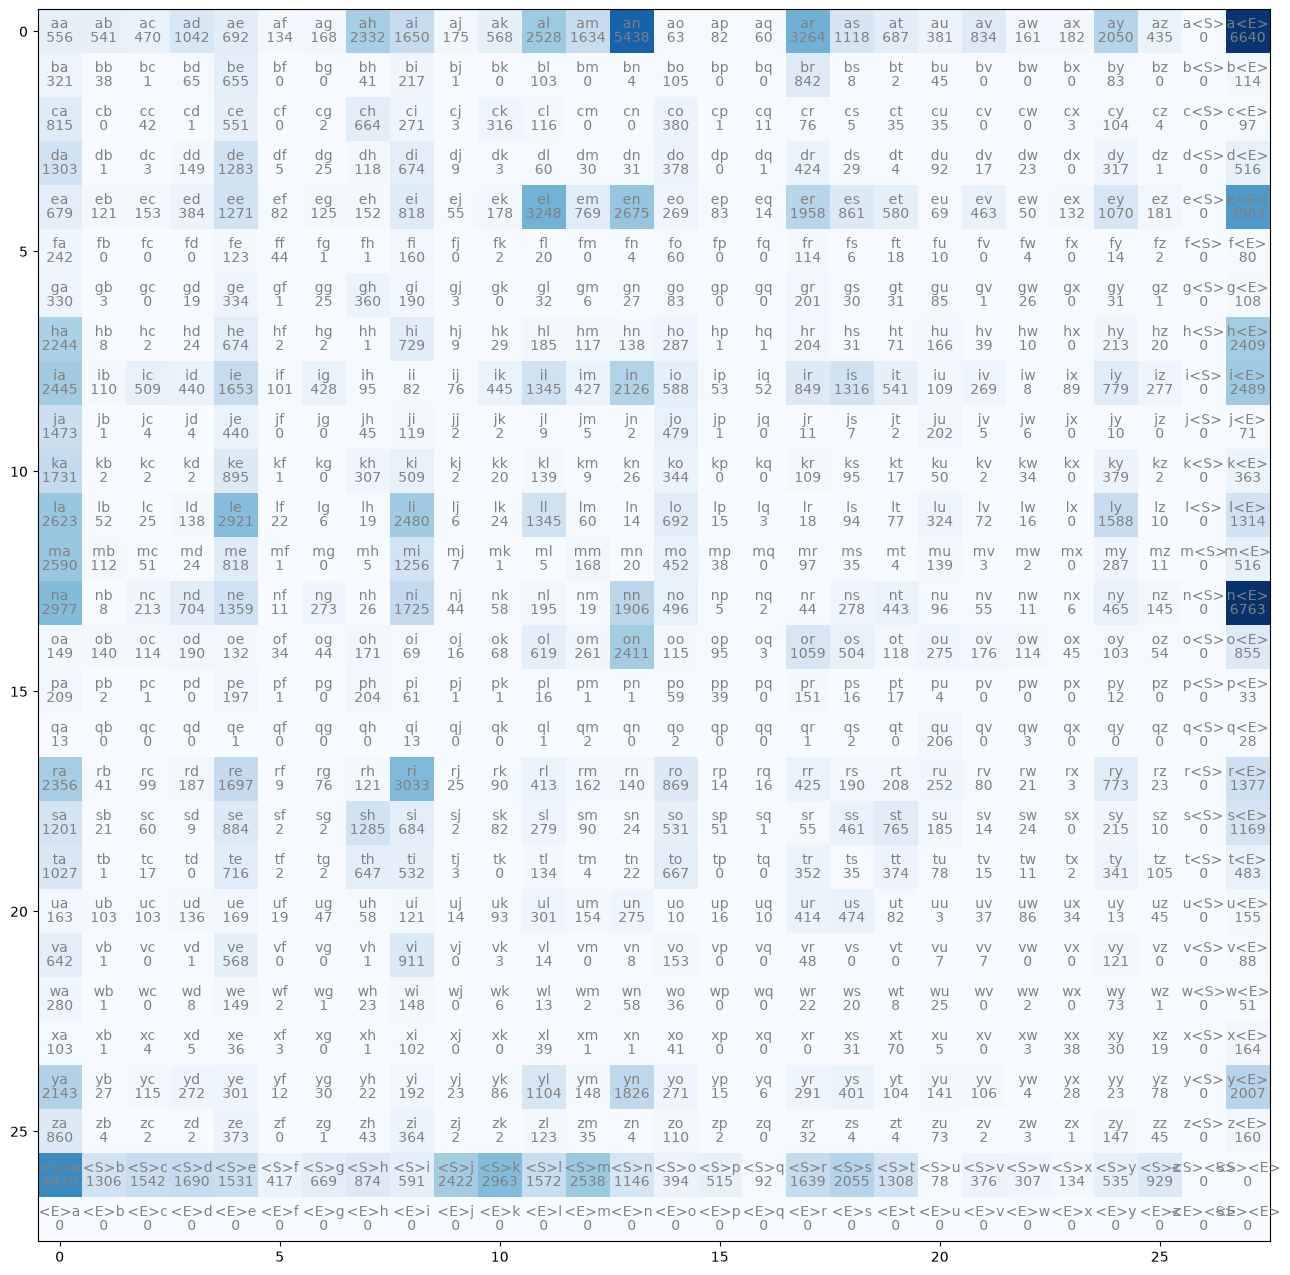

In [41]:

itos = {i:s for s,i in stoi.items()}

plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color="gray")
        plt.text(j,i,N[i,j].item(),ha="center",va="top",color="gray")